# India Food Delivery Time - EDA



## 1. Import Libraries

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns


## 2. Load the Data

In [2]:

df = pd.read_json('India-Food-Delivery-Time-Prediction.txt')
df.shape

(41953, 20)

In [3]:
df.head()

,ID,Delivery_person_ID,Delivery_person_Age,Delivery_person_Ratings,Restaurant_latitude,Restaurant_longitude,Delivery_location_latitude,Delivery_location_longitude,Order_Date,Time_Orderd,Time_Order_picked,Weatherconditions,Road_traffic_density,Vehicle_condition,Type_of_order,Type_of_vehicle,multiple_deliveries,Festival,City,Time_taken(min)
0,0x4607,INDORES13DEL02,37.0,4.9,22.745049,75.892471,22.765049,75.912471,19-03-2022,11:33:33,11:45:29,conditions Sunny,High,2,Snack,motorcycle,0.0,No,Urban,(min) 24
1,0xb379,BANGRES18DEL02,34.0,4.5,12.913041,77.683237,13.043041,77.813237,25-03-2022,19:45:37,19:51:49,conditions Stormy,Jam,2,Snack,scooter,1.0,No,Metropolitian,(min) 33
2,0x5d6d,BANGRES19DEL01,23.0,4.4,12.914264,77.678400,12.924264,77.688400,19-03-2022,8:32:58,8:48:47,conditions Sandstorms,Low,0,Drinks,motorcycle,1.0,No,Urban,(min) 26
3,0x7a6a,COIMBRES13DEL02,38.0,4.7,11.003669,76.976494,11.053669,77.026494,05-04-2022,18:03:58,18:12:52,conditions Sunny,Medium,0,Buffet,motorcycle,1.0,No,Metropolitian,(min) 21
4,0x70a2,CHENRES12DEL01,32.0,4.6,12.972793,80.249982,13.012793,80.289982,26-03-2022,13:34:16,13:45:36,conditions Cloudy,High,1,Snack,scooter,1.0,No,Metropolitian,(min) 30


In [4]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 41953 entries, 0 to 41952
Data columns (total 20 columns):
 #   Column                       Non-Null Count  Dtype  
---  ------                       --------------  -----  
 0   ID                           41953 non-null  str    
 1   Delivery_person_ID           41953 non-null  str    
 2   Delivery_person_Age          40234 non-null  float64
 3   Delivery_person_Ratings      40190 non-null  float64
 4   Restaurant_latitude          41953 non-null  float64
 5   Restaurant_longitude         41953 non-null  float64
 6   Delivery_location_latitude   41953 non-null  float64
 7   Delivery_location_longitude  41953 non-null  float64
 8   Order_Date                   41953 non-null  str    
 9   Time_Orderd                  40353 non-null  str    
 10  Time_Order_picked            41953 non-null  str    
 11  Weatherconditions            41953 non-null  str    
 12  Road_traffic_density         41953 non-null  str    
 13  Vehicle_condition          

In [5]:
df.isna().sum()

ID                                0
Delivery_person_ID                0
Delivery_person_Age            1719
Delivery_person_Ratings        1763
Restaurant_latitude               0
Restaurant_longitude              0
Delivery_location_latitude        0
Delivery_location_longitude       0
Order_Date                        0
Time_Orderd                    1600
Time_Order_picked                 0
Weatherconditions                 0
Road_traffic_density              0
Vehicle_condition                 0
Type_of_order                     0
Type_of_vehicle                   0
multiple_deliveries             905
Festival                          0
City                              0
Time_taken(min)                   0
dtype: int64

In [6]:
df.describe()

,Delivery_person_Age,Delivery_person_Ratings,Restaurant_latitude,Restaurant_longitude,Delivery_location_latitude,Delivery_location_longitude,Vehicle_condition,multiple_deliveries
count,40234.000000,40190.000000,41953.000000,41953.000000,41953.000000,41953.000000,41953.000000,41048.000000
mean,29.563330,4.632386,18.911397,76.923408,18.975064,76.987074,1.022716,0.745249
std,5.812361,0.335541,5.467829,3.502910,5.469616,3.503073,0.838893,0.572152
min,15.000000,1.000000,9.957144,72.768726,9.967144,72.778726,0.000000,0.000000
25%,25.000000,4.500000,12.986047,73.898520,13.065996,73.940327,0.000000,0.000000
50%,30.000000,4.700000,19.065838,76.618203,19.123249,76.663622,1.000000,1.000000
75%,35.000000,4.900000,22.751234,78.368855,22.820040,78.405467,2.000000,1.000000
max,50.000000,6.000000,30.914057,88.433452,31.054057,88.563452,3.000000,3.000000


In [7]:
df.describe(include="object")

C:\Users\pushk\AppData\Local\Temp\ipykernel_30540\702825166.py:1: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  df.describe(include="object")


,ID,Delivery_person_ID,Order_Date,Time_Orderd,Time_Order_picked,Weatherconditions,Road_traffic_density,Type_of_order,Type_of_vehicle,Festival,City,Time_taken(min)
count,41953,41953,41953,40353,41953,41953,41953,41953,41953,41953,41953,41953
unique,41953,1170,44,25569,26949,7,5,4,4,3,4,45
top,0x4607,JAPRES11DEL02,15-03-2022,20:32:38,0:00:12,conditions Fog,Low,Snack,motorcycle,No,Metropolitian,(min) 26
freq,1,67,1115,8,8,7012,14200,10616,24396,40916,31411,1960


## 3. Clean the Data


In [8]:
text_cols = df.describe(include="object").columns
text_cols

C:\Users\pushk\AppData\Local\Temp\ipykernel_30540\1438647685.py:1: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  text_cols = df.describe(include="object").columns


Index(['ID', 'Delivery_person_ID', 'Order_Date', 'Time_Orderd',
       'Time_Order_picked', 'Weatherconditions', 'Road_traffic_density',
       'Type_of_order', 'Type_of_vehicle', 'Festival', 'City',
       'Time_taken(min)'],
      dtype='str')

In [9]:
for col in text_cols:
    df[col] = df[col].str.strip()

In [10]:
df[text_cols].value_counts()

ID      Delivery_person_ID  Order_Date  Time_Orderd  Time_Order_picked  Weatherconditions      Road_traffic_density  Type_of_order  Type_of_vehicle  Festival  City           Time_taken(min)
0x4607  INDORES13DEL02      19-03-2022  11:33:33     11:45:29           conditions Sunny       High                  Snack          motorcycle       No        Urban          (min) 24           1
0xb379  BANGRES18DEL02      25-03-2022  19:45:37     19:51:49           conditions Stormy      Jam                   Snack          scooter          No        Metropolitian  (min) 33           1
0x5d6d  BANGRES19DEL01      19-03-2022  8:32:58      8:48:47            conditions Sandstorms  Low                   Drinks         motorcycle       No        Urban          (min) 26           1
0x7a6a  COIMBRES13DEL02     05-04-2022  18:03:58     18:12:52           conditions Sunny       Medium                Buffet         motorcycle       No        Metropolitian  (min) 21           1
0x70a2  CHENRES12DEL01      26

weather column contains "conditons" in every row

In [11]:
df['Weatherconditions'] = df['Weatherconditions'].str.replace('conditions ', '',)
df["Weatherconditions"]

0             Sunny
1            Stormy
2        Sandstorms
3             Sunny
4            Cloudy
            ...    
41948         Windy
41949         Windy
41950        Cloudy
41951        Cloudy
41952           Fog
Name: Weatherconditions, Length: 41953, dtype: str

time taken column contains min in every rows  

In [12]:
df['Time_taken(min)'] = df['Time_taken(min)'].str.replace('(min) ', '').astype(int)
df["Time_taken(min)"]

0        24
1        33
2        26
3        21
4        30
         ..
41948    33
41949    32
41950    16
41951    26
41952    36
Name: Time_taken(min), Length: 41953, dtype: int32

some of the colummn contains "NaN" as value

In [13]:
df = df.replace('NaN', np.nan)

In [14]:
df.isna().sum()

ID                                0
Delivery_person_ID                0
Delivery_person_Age            1719
Delivery_person_Ratings        1763
Restaurant_latitude               0
Restaurant_longitude              0
Delivery_location_latitude        0
Delivery_location_longitude       0
Order_Date                        0
Time_Orderd                    1600
Time_Order_picked                 0
Weatherconditions               569
Road_traffic_density            555
Vehicle_condition                 0
Type_of_order                     0
Type_of_vehicle                   0
multiple_deliveries             905
Festival                        215
City                           1114
Time_taken(min)                   0
dtype: int64

In [15]:
df['Order_Date'] = pd.to_datetime(df['Order_Date'])
df['Order_Date']

C:\Users\pushk\AppData\Local\Temp\ipykernel_30540\1274789187.py:1: UserWarning: Parsing dates in %d-%m-%Y format when dayfirst=False (the default) was specified. Pass `dayfirst=True` or specify a format to silence this warning.
  df['Order_Date'] = pd.to_datetime(df['Order_Date'])


0       2022-03-19
1       2022-03-25
2       2022-03-19
3       2022-04-05
4       2022-03-26
           ...    
41948   2022-03-08
41949   2022-03-24
41950   2022-03-11
41951   2022-03-07
41952   2022-03-02
Name: Order_Date, Length: 41953, dtype: datetime64[us]

In [16]:
df['Time_Orderd'] = pd.to_datetime(df['Time_Orderd'])
df['Time_Orderd']

C:\Users\pushk\AppData\Local\Temp\ipykernel_30540\934927352.py:1: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  df['Time_Orderd'] = pd.to_datetime(df['Time_Orderd'])


0       2026-09-17 11:33:33
1       2026-09-17 19:45:37
2       2026-09-17 08:32:58
3       2026-09-17 18:03:58
4       2026-09-17 13:34:16
                ...        
41948   2026-09-17 21:47:47
41949   2026-09-17 11:36:22
41950   2026-09-17 23:50:56
41951   2026-09-17 13:40:13
41952   2026-09-17 17:12:55
Name: Time_Orderd, Length: 41953, dtype: datetime64[us]

In [17]:
df['Time_Orderd'] = df['Time_Orderd'].dt.time
df["Time_Orderd"]

0        11:33:33
1        19:45:37
2        08:32:58
3        18:03:58
4        13:34:16
           ...   
41948    21:47:47
41949    11:36:22
41950    23:50:56
41951    13:40:13
41952    17:12:55
Name: Time_Orderd, Length: 41953, dtype: object

In [18]:
df['Time_Order_picked'] = pd.to_datetime(df['Time_Order_picked']).dt.time 
df['Time_Order_picked']

C:\Users\pushk\AppData\Local\Temp\ipykernel_30540\3935431051.py:1: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  df['Time_Order_picked'] = pd.to_datetime(df['Time_Order_picked']).dt.time


0        11:45:29
1        19:51:49
2        08:48:47
3        18:12:52
4        13:45:36
           ...   
41948    21:59:27
41949    11:48:07
41950    00:08:55
41951    13:42:00
41952    17:19:35
Name: Time_Order_picked, Length: 41953, dtype: object

In [19]:
df.head()

,ID,Delivery_person_ID,Delivery_person_Age,Delivery_person_Ratings,Restaurant_latitude,Restaurant_longitude,Delivery_location_latitude,Delivery_location_longitude,Order_Date,Time_Orderd,Time_Order_picked,Weatherconditions,Road_traffic_density,Vehicle_condition,Type_of_order,Type_of_vehicle,multiple_deliveries,Festival,City,Time_taken(min)
0,0x4607,INDORES13DEL02,37.0,4.9,22.745049,75.892471,22.765049,75.912471,2022-03-19,11:33:33,11:45:29,Sunny,High,2,Snack,motorcycle,0.0,No,Urban,24
1,0xb379,BANGRES18DEL02,34.0,4.5,12.913041,77.683237,13.043041,77.813237,2022-03-25,19:45:37,19:51:49,Stormy,Jam,2,Snack,scooter,1.0,No,Metropolitian,33
2,0x5d6d,BANGRES19DEL01,23.0,4.4,12.914264,77.678400,12.924264,77.688400,2022-03-19,08:32:58,08:48:47,Sandstorms,Low,0,Drinks,motorcycle,1.0,No,Urban,26
3,0x7a6a,COIMBRES13DEL02,38.0,4.7,11.003669,76.976494,11.053669,77.026494,2022-04-05,18:03:58,18:12:52,Sunny,Medium,0,Buffet,motorcycle,1.0,No,Metropolitian,21
4,0x70a2,CHENRES12DEL01,32.0,4.6,12.972793,80.249982,13.012793,80.289982,2022-03-26,13:34:16,13:45:36,Cloudy,High,1,Snack,scooter,1.0,No,Metropolitian,30


## 4. Missing Values

In [20]:
df.isnull().sum()

ID                                0
Delivery_person_ID                0
Delivery_person_Age            1719
Delivery_person_Ratings        1763
Restaurant_latitude               0
Restaurant_longitude              0
Delivery_location_latitude        0
Delivery_location_longitude       0
Order_Date                        0
Time_Orderd                    1600
Time_Order_picked                 0
Weatherconditions               569
Road_traffic_density            555
Vehicle_condition                 0
Type_of_order                     0
Type_of_vehicle                   0
multiple_deliveries             905
Festival                        215
City                           1114
Time_taken(min)                   0
dtype: int64

<Axes: xlabel='Delivery_person_Age', ylabel='Count'>

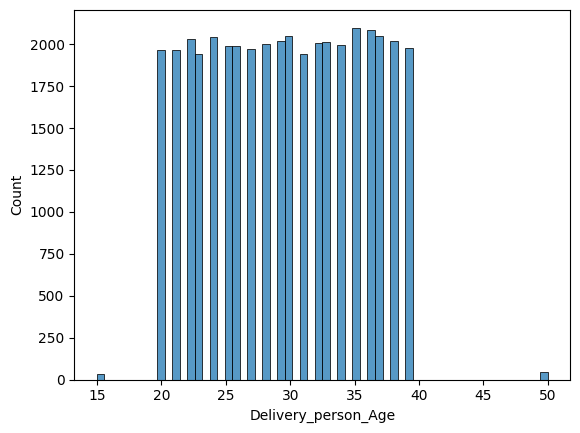

In [21]:
sns.histplot(df["Delivery_person_Age"])

In [22]:
median_age = df["Delivery_person_Age"].median()
df["Delivery_person_Age"] = df["Delivery_person_Age"].fillna(median_age)

<Axes: xlabel='Delivery_person_Age', ylabel='Count'>

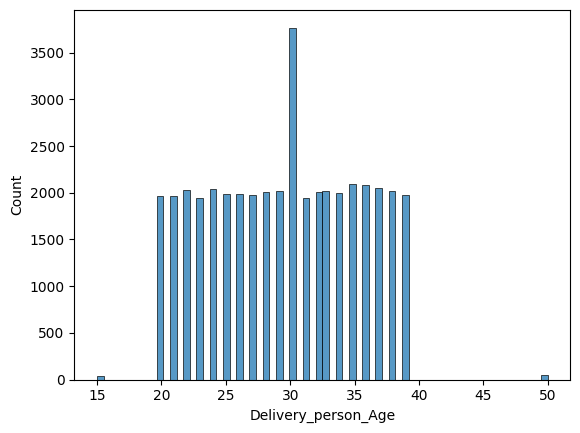

In [23]:
sns.histplot(df["Delivery_person_Age"])

In [24]:
df["Delivery_person_Age"].isna().sum()

0

<Axes: xlabel='Delivery_person_Ratings', ylabel='Count'>

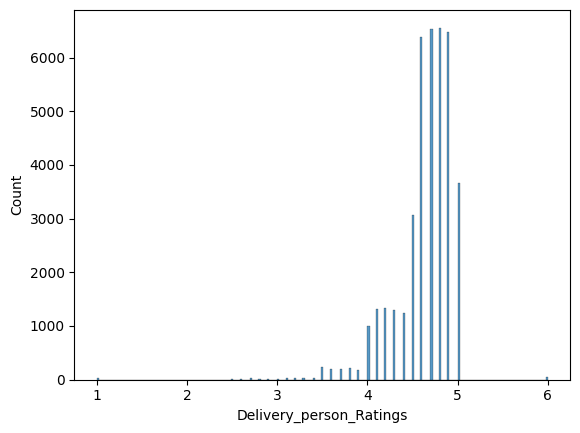

In [25]:
sns.histplot(df["Delivery_person_Ratings"])

filled rating of the delivery person with the individual median ratings

In [26]:
df["Delivery_person_ID"].nunique()

1170

In [27]:
median_rating = df.groupby("Delivery_person_ID")["Delivery_person_Ratings"].median()
median_rating

Delivery_person_ID
AGRRES010DEL01    4.80
AGRRES010DEL02    4.85
AGRRES010DEL03    4.70
AGRRES01DEL01     4.70
AGRRES01DEL02     4.70
                  ... 
VADRES19DEL02     4.70
VADRES19DEL03     4.70
VADRES20DEL01     4.70
VADRES20DEL02     4.70
VADRES20DEL03     4.80
Name: Delivery_person_Ratings, Length: 1170, dtype: float64

In [28]:
df["Delivery_person_Ratings"]=df["Delivery_person_Ratings"].fillna(df["Delivery_person_ID"].map(median_rating))

In [29]:
df["Delivery_person_Ratings"].isna().sum()

0

In [30]:
df["Weatherconditions"].isna().sum()

569

there are   569 null values in the weather columns 

In [31]:
df["Weatherconditions"].value_counts()

Weatherconditions
Fog           7012
Stormy        6974
Cloudy        6932
Sandstorms    6906
Windy         6832
Sunny         6728
Name: count, dtype: int64

In [32]:

df["Weatherconditions"] = df["Weatherconditions"].fillna("Sunny")

In [33]:
mode_traffic = df.groupby("Festival")["Road_traffic_density"].apply(lambda x: x.mode()[0])


In [34]:
mode_traffic

Festival
No     Low
Yes    Jam
Name: Road_traffic_density, dtype: str

In [35]:
df["Festival"] = df["Festival"].fillna("No")

In [36]:
df["Road_traffic_density"] = df["Road_traffic_density"].fillna(df["Festival"].map(mode_traffic))

In [37]:

df["multiple_deliveries"] = df["multiple_deliveries"].fillna(0)

In [38]:
df["City"].value_counts()

City
Metropolitian    31411
Urban             9279
Semi-Urban         149
Name: count, dtype: int64

In [39]:
df["City"]= df["City"].fillna("Others")

In [40]:
mode_time = df["Time_Orderd"].mode()

In [41]:
df.loc[df["Time_Orderd"].isna()]

,ID,Delivery_person_ID,Delivery_person_Age,Delivery_person_Ratings,Restaurant_latitude,Restaurant_longitude,Delivery_location_latitude,Delivery_location_longitude,Order_Date,Time_Orderd,Time_Order_picked,Weatherconditions,Road_traffic_density,Vehicle_condition,Type_of_order,Type_of_vehicle,multiple_deliveries,Festival,City,Time_taken(min)
41,0x4f0,MUMRES17DEL02,30.0,4.7,19.121999,72.908493,19.201999,72.988493,2022-04-06,NaT,18:36:55,Cloudy,Medium,1,Drinks,scooter,1.0,No,Metropolitian,33
66,0xa9f,BANGRES13DEL01,30.0,4.7,12.935662,77.614130,12.975662,77.654130,2022-03-11,NaT,15:31:11,Sunny,Low,1,Drinks,scooter,0.0,No,Metropolitian,19
110,0x6e2,VADRES06DEL01,30.0,4.7,22.312790,73.170283,22.422790,73.280283,2022-04-02,NaT,18:26:07,Sunny,Low,3,Snack,electric_scooter,0.0,No,Metropolitian,25
129,0x1ec7,PUNERES05DEL03,30.0,4.6,18.543626,73.905101,18.573626,73.935101,2022-03-09,NaT,23:41:40,Stormy,Low,2,Snack,scooter,0.0,No,Others,19
162,0x1b58,JAPRES03DEL01,30.0,4.7,26.913483,75.803139,26.983483,75.873139,2022-03-12,NaT,17:50:59,Sandstorms,Medium,0,Drinks,motorcycle,0.0,No,Metropolitian,43
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
41784,0xc7ed,KNPRES20DEL03,30.0,4.6,26.470000,80.350000,26.610000,80.490000,2022-02-12,NaT,19:26:52,Windy,Jam,1,Drinks,scooter,1.0,No,Metropolitian,18
41874,0x461,BANGRES07DEL02,30.0,4.7,12.978453,77.643685,12.998453,77.663685,2022-03-17,NaT,09:30:06,Sunny,Low,3,Meal,scooter,1.0,No,Others,24
41887,0x863,INDORES05DEL01,30.0,4.7,22.727021,75.884167,22.737021,75.894167,2022-03-19,NaT,11:44:45,Sunny,Low,3,Snack,electric_scooter,0.0,No,Metropolitian,25
41888,0xd0be,AGRRES07DEL01,30.0,4.7,27.160934,78.044095,27.170934,78.054095,2022-02-13,NaT,09:09:31,Sunny,Low,3,Meal,electric_scooter,1.0,No,Urban,17


In [42]:
df['Time_Orderd'] = pd.to_datetime(df['Time_Orderd'].astype(str))
df['Time_Order_picked'] = pd.to_datetime(df['Time_Order_picked'].astype(str))

C:\Users\pushk\AppData\Local\Temp\ipykernel_30540\3201616026.py:1: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  df['Time_Orderd'] = pd.to_datetime(df['Time_Orderd'].astype(str))
C:\Users\pushk\AppData\Local\Temp\ipykernel_30540\3201616026.py:2: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  df['Time_Order_picked'] = pd.to_datetime(df['Time_Order_picked'].astype(str))


In [43]:
avg_process_time = (df["Time_Order_picked"]-df["Time_Orderd"]).mean()

In [44]:
df['Time_Orderd'] = (df['Time_Orderd'].fillna(df['Time_Order_picked'] - avg_process_time).dt.time)

In [45]:
df.isna().sum()

ID                             0
Delivery_person_ID             0
Delivery_person_Age            0
Delivery_person_Ratings        0
Restaurant_latitude            0
Restaurant_longitude           0
Delivery_location_latitude     0
Delivery_location_longitude    0
Order_Date                     0
Time_Orderd                    0
Time_Order_picked              0
Weatherconditions              0
Road_traffic_density           0
Vehicle_condition              0
Type_of_order                  0
Type_of_vehicle                0
multiple_deliveries            0
Festival                       0
City                           0
Time_taken(min)                0
dtype: int64

# outliers detection 

In [46]:
df.loc[df["Delivery_person_Ratings"]>5]["Delivery_person_Ratings"].sum()

# there are 276 fake ratings having rating more than 5

276.0

In [47]:
num_cols = df.describe().columns
col_to_check = ['Delivery_person_Age', 'Delivery_person_Ratings', 'multiple_deliveries', 'Time_taken(min)']

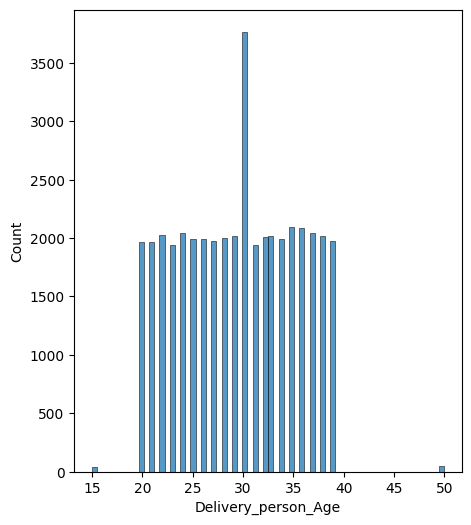

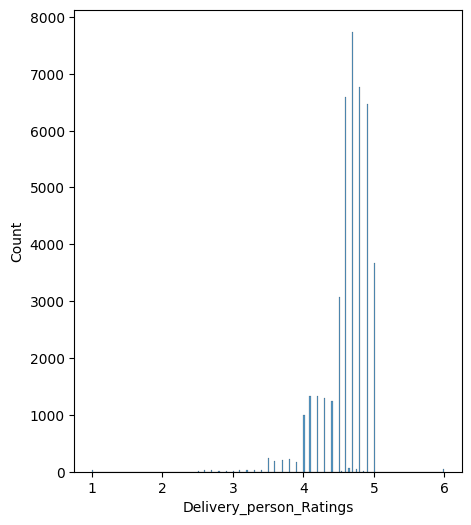

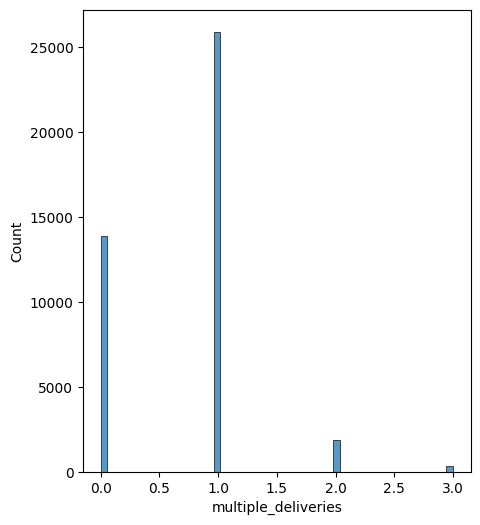

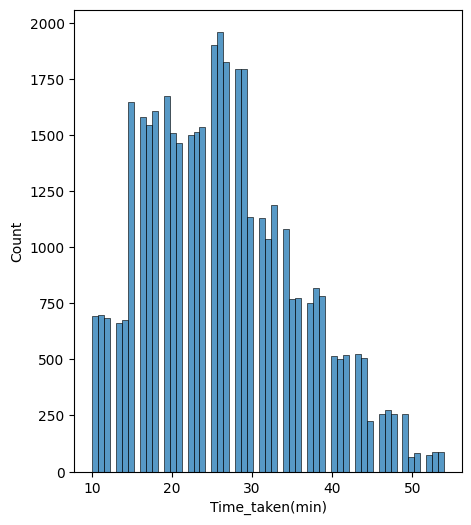

In [48]:
for i in col_to_check:
    plt.figure(figsize=(5,6))
    sns.histplot(df[i])

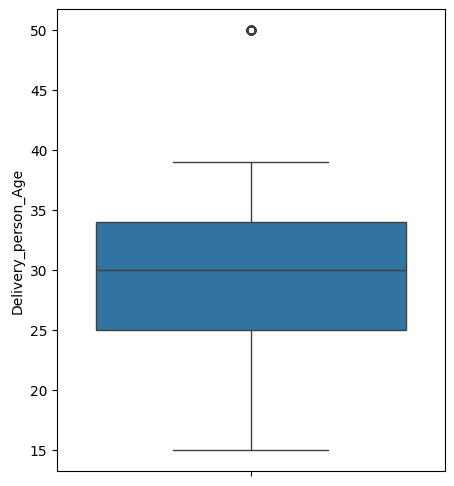

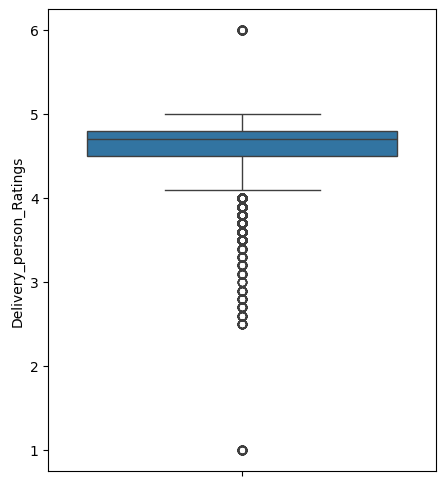

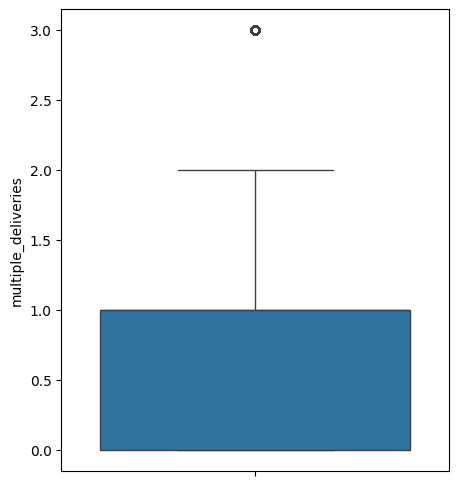

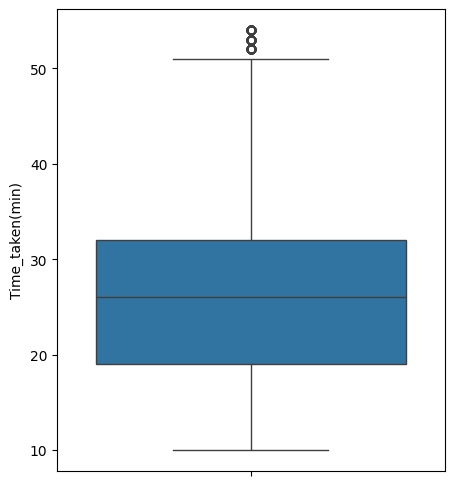

In [49]:
for i in col_to_check:
    plt.figure(figsize=(5,6))
    sns.boxplot(df[i])

In [50]:
df["Delivery_person_Ratings"] = df["Delivery_person_Ratings"].clip(1,5)

## 5. Summary Statistics

In [51]:
df.describe()

,Delivery_person_Age,Delivery_person_Ratings,Restaurant_latitude,Restaurant_longitude,Delivery_location_latitude,Delivery_location_longitude,Order_Date,Time_Order_picked,Vehicle_condition,multiple_deliveries,Time_taken(min)
count,41953.000000,41953.000000,41953.000000,41953.000000,41953.000000,41953.000000,41953,41953,41953.000000,41953.000000,41953.000000
mean,29.581222,4.634093,18.911397,76.923408,18.975064,76.987074,2022-03-14 04:37:32.692298,2026-09-17 17:39:51.540199,1.022716,0.729173,26.311539
min,15.000000,1.000000,9.957144,72.768726,9.967144,72.778726,2022-02-11 00:00:00,2026-09-17 00:00:02,0.000000,0.000000,10.000000
25%,25.000000,4.500000,12.986047,73.898520,13.065996,73.940327,2022-03-05 00:00:00,2026-09-17 14:37:04,0.000000,0.000000,19.000000
50%,30.000000,4.700000,19.065838,76.618203,19.123249,76.663622,2022-03-15 00:00:00,2026-09-17 19:12:09,1.000000,1.000000,26.000000
75%,34.000000,4.800000,22.751234,78.368855,22.820040,78.405467,2022-03-27 00:00:00,2026-09-17 21:37:15,2.000000,1.000000,32.000000
max,50.000000,5.000000,30.914057,88.433452,31.054057,88.563452,2022-04-06 00:00:00,2026-09-17 23:59:57,3.000000,3.000000,54.000000
std,5.692692,0.325980,5.467829,3.502910,5.469616,3.503073,NaN,NaN,0.838893,0.576211,9.380753


In [52]:
df.describe(include='object')

C:\Users\pushk\AppData\Local\Temp\ipykernel_30540\87514550.py:1: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  df.describe(include='object')


,ID,Delivery_person_ID,Time_Orderd,Weatherconditions,Road_traffic_density,Type_of_order,Type_of_vehicle,Festival,City
count,41953,41953,41953,41953,41953,41953,41953,41953,41953
unique,41953,1170,27134,6,4,4,4,2,4
top,0x4607,JAPRES11DEL02,20:32:38,Sunny,Low,Snack,motorcycle,No,Metropolitian
freq,1,67,8,7297,14741,10616,24396,41131,31411


## 6. Target Variable: Time Taken

Text(0.5, 0, 'Time Taken (min)')

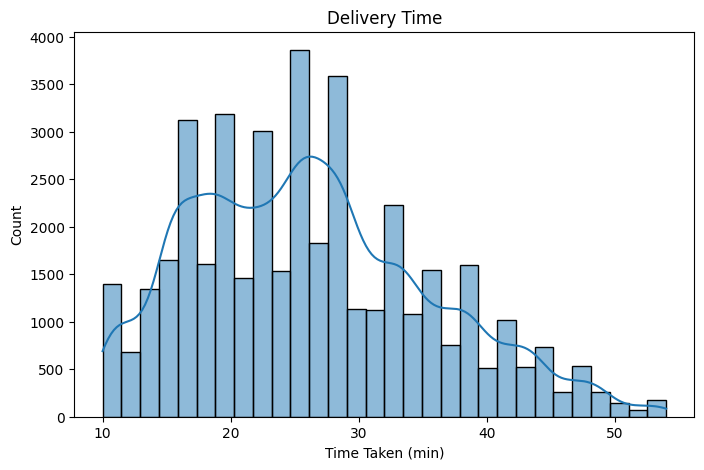

In [53]:
plt.figure(figsize=(8, 5))
sns.histplot(df['Time_taken(min)'], bins=30, kde=True)
plt.title('Delivery Time')
plt.xlabel('Time Taken (min)')


Delivery times show a right-skewed, multimodal distribution centered primarily between 15 and 30 minutes, peaking around 26 minutes and dropping sharply after 40 minutes.

In [54]:
print('Average delivery time:', round(df['Time_taken(min)'].mean(), 2), 'minutes')
print('Minimum delivery time:', df['Time_taken(min)'].min(), 'minutes')
print('Maximum delivery time:', df['Time_taken(min)'].max(), 'minutes')

Average delivery time: 26.31 minutes
Minimum delivery time: 10 minutes
Maximum delivery time: 54 minutes


## 7. Categorical Columns

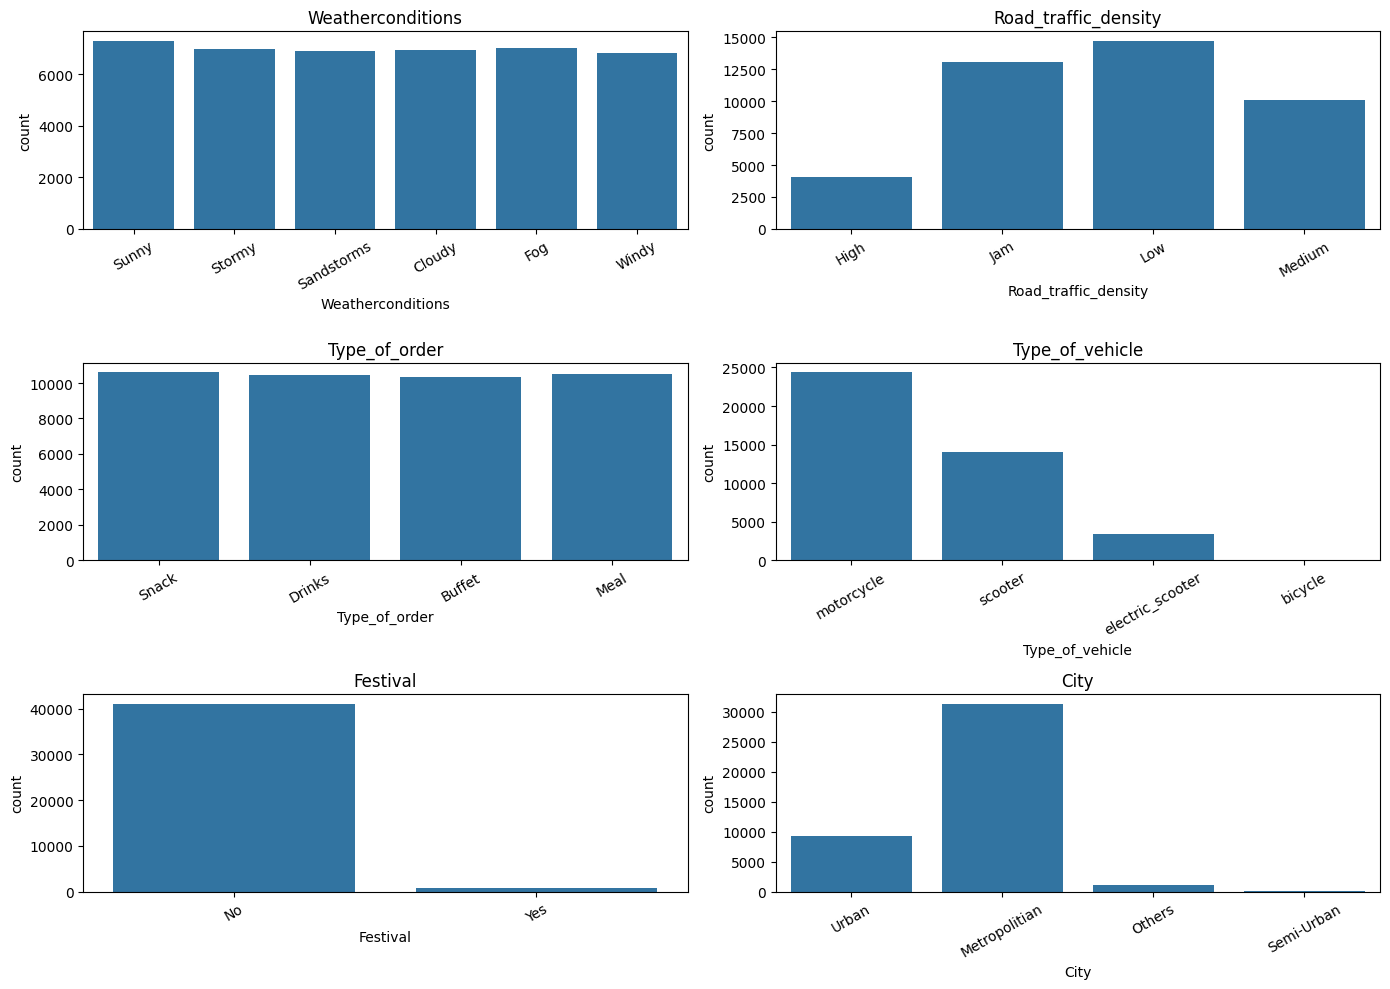

In [55]:
cat_cols = ['Weatherconditions', 'Road_traffic_density', 'Type_of_order',
            'Type_of_vehicle', 'Festival', 'City']

plt.figure(figsize=(14, 10))
for i, col in enumerate(cat_cols):
    plt.subplot(3, 2, i + 1)
    sns.countplot(data=df, x=col)
    plt.title(col)
    plt.xticks(rotation=30)
plt.tight_layout()
plt.show()

* Weatherconditions: Orders are evenly balanced across all weather types (~7,000 counts each), indicating weather has little to no impact on overall order volume.
* Road_traffic_density: Deliveries are most frequent during Low and Jam traffic conditions (>12,500 each), while High traffic accounts for the smallest share (~4,000).
* Type_of_order: Demand is uniformly distributed across Snacks, Drinks, Buffets, and Meals at roughly 10,000–11,000 orders each.
* Type_of_vehicle: Two-wheelers dominate delivery fulfillment, with motorcycles being the primary vehicle (>24,000), followed by scooters (~14,000), while bicycles are virtually unused.
* Festival: An overwhelming majority (>40,000) of orders take place during regular, non-festival days compared to festival periods (<1,000).
* City: Operations are heavily concentrated in Metropolitan areas (>30,000 orders), followed moderately by Urban zones (~9,000), with negligible volume in Semi-Urban and Other areas.

## 8. Numeric Columns

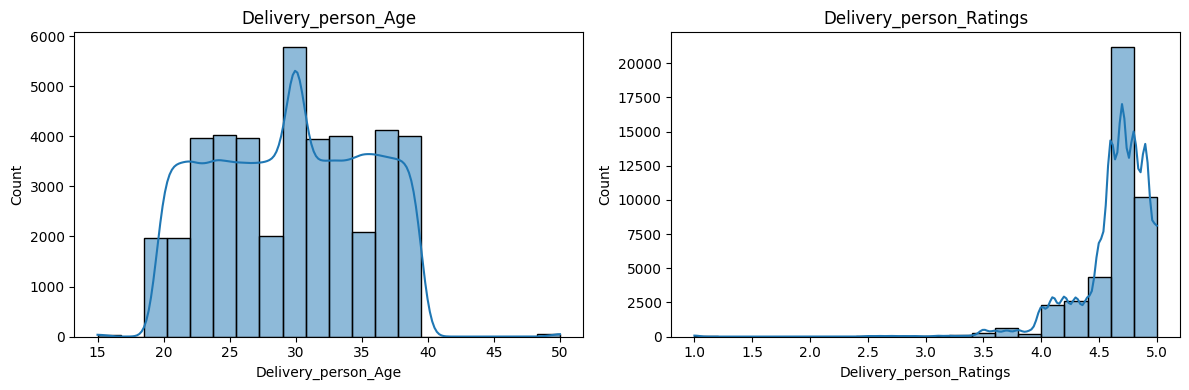

In [56]:
num_cols = ['Delivery_person_Age', 'Delivery_person_Ratings']

plt.figure(figsize=(12, 4))
for i, col in enumerate(num_cols):
    plt.subplot(1, 2, i + 1)
    sns.histplot(df[col].dropna(), bins=20, kde=True)
    plt.title(col)
plt.tight_layout()
plt.show()

* Delivery_person_Age: The age distribution is largely uniform between 20 and 40 years (~3,500–4,000 counts per bin) with a pronounced spike near age 30 (~5,800 counts), likely due to median/mode imputation.


* Delivery_person_Ratings: Ratings are heavily left-skewed toward high performance, with the vast majority of scores clustered between 4.6 and 5.0 (peaking above 21,000 counts) and virtually no ratings below 3.5.

## 9. Delivery Time vs Categorical Columns

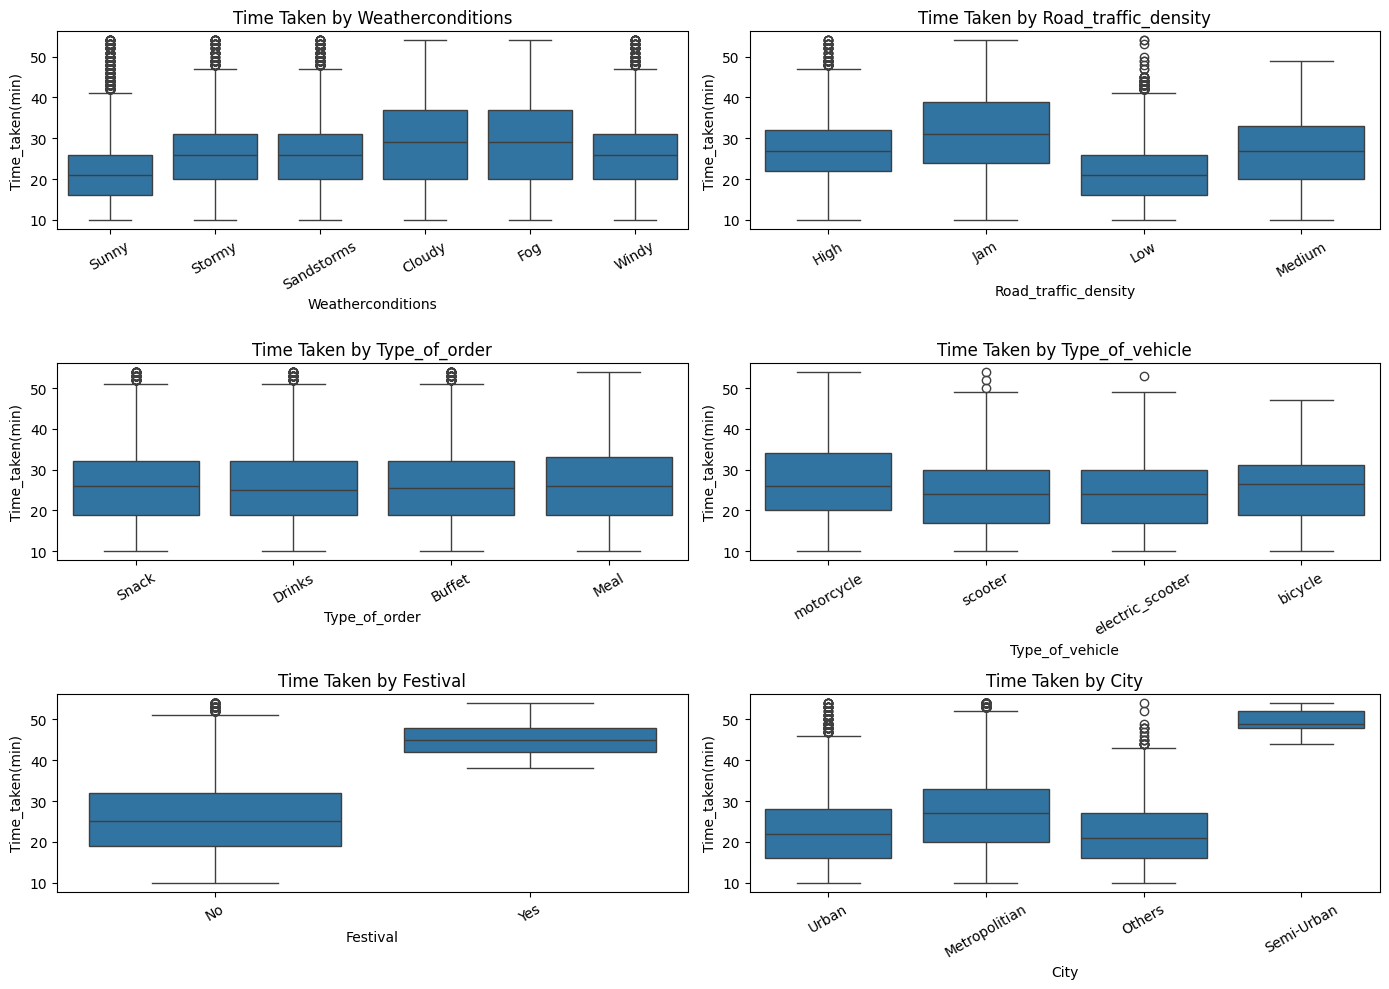

In [57]:
plt.figure(figsize=(14, 10))
for i, col in enumerate(cat_cols):
    plt.subplot(3, 2, i + 1)
    sns.boxplot(data=df, x=col, y='Time_taken(min)')
    plt.title(f'Time Taken by {col}')
    plt.xticks(rotation=30)
plt.tight_layout()
plt.show()

* Weather: Cloudy and foggy cause delays.
* Traffic: Traffic jams slow deliveries most.
* Order Type: Order type does not matter.
* Vehicle Type: Scooters deliver slightly faster overall.
* Festival: Festivals cause severe delivery delays.
* City: Semi-Urban deliveries take longest.

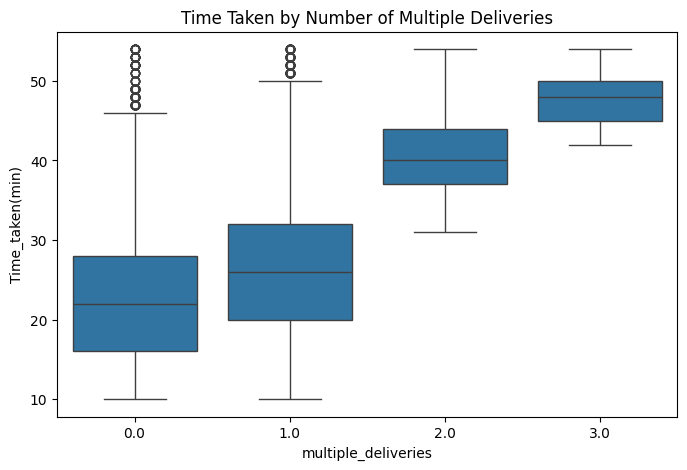

In [61]:
plt.figure(figsize=(8, 5))
sns.boxplot(data=df, x='multiple_deliveries', y='Time_taken(min)')
plt.title('Time Taken by Number of Multiple Deliveries')
plt.show()

More deliveries increase delivery time

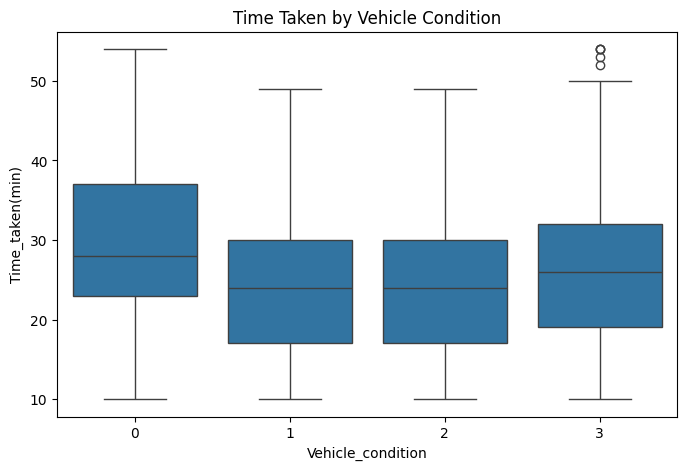

In [62]:
plt.figure(figsize=(8, 5))
sns.boxplot(data=df, x='Vehicle_condition', y='Time_taken(min)')
plt.title('Time Taken by Vehicle Condition')
plt.show()

poor vehicle condition causes late delivery 

## 12. Delivery Time by Order Hour and Day

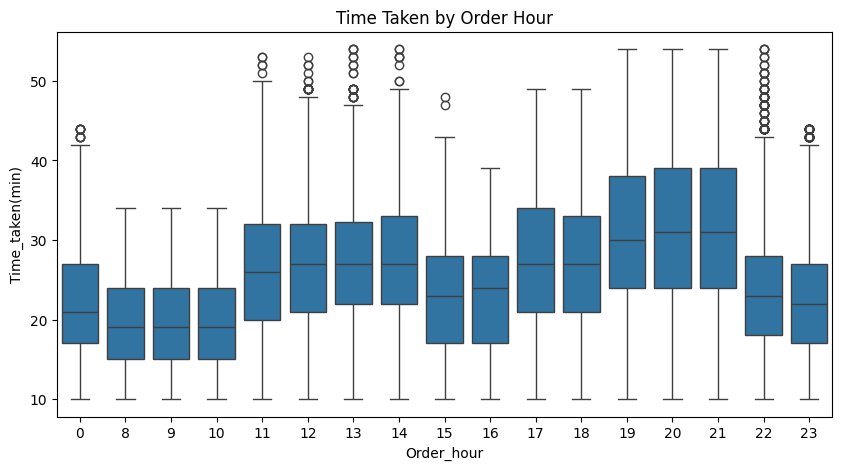

In [ ]:

df['Order_hour'] = df['Time_Orderd'].apply(lambda t: t.hour if pd.notnull(t) else np.nan)

plt.figure(figsize=(10, 5))
sns.boxplot(data=df, x='Order_hour', y='Time_taken(min)')
plt.title('Time Taken by Order Hour')
plt.show()

Evening peak hours take longest.

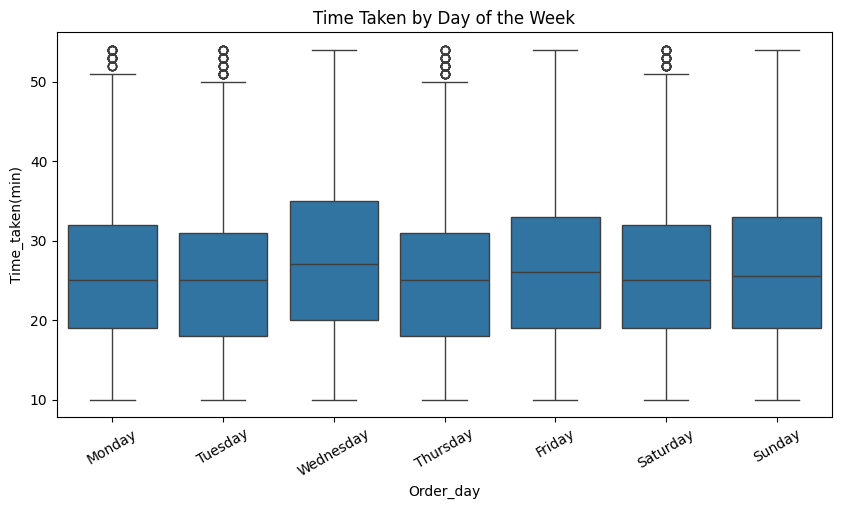

In [ ]:

df['Order_day'] = df['Order_Date'].dt.day_name()

plt.figure(figsize=(10, 5))
order = ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday']
sns.boxplot(data=df, x='Order_day', y='Time_taken(min)', order=order)
plt.title('Time Taken by Day of the Week')
plt.xticks(rotation=30)
plt.show()

days of week make very less impact on delivery time

## 13. Correlation Between Numeric Columns

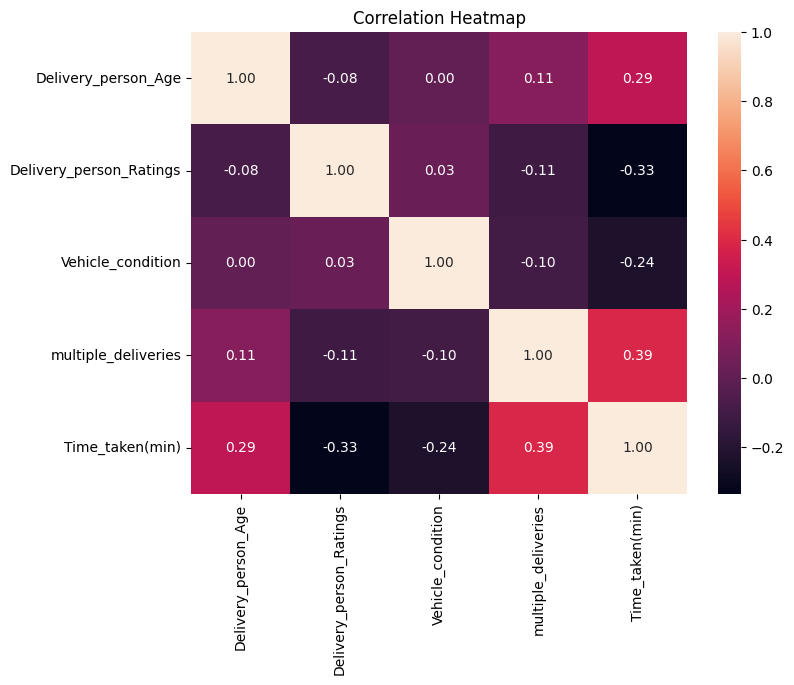

In [ ]:
numeric_df = df[['Delivery_person_Age', 'Delivery_person_Ratings','Vehicle_condition','multiple_deliveries', 'Time_taken(min)']]

plt.figure(figsize=(8, 6))
sns.heatmap(numeric_df.corr(), annot=True, fmt='.2f')
plt.title('Correlation Heatmap')
plt.show()

* Multiple deliveries delay orders most: Has the strongest positive correlation with delivery time (+0.39).
* Higher ratings mean faster delivery: Strongest negative correlation (-0.33); top-rated partners complete trips faster.
* Older age increases time: Driver age is moderately positively correlated with delivery duration (+0.29).
* Better vehicles reduce time: Improved vehicle condition correlates with shorter delivery times (-0.24).